In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib import colormaps
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from matplotlib.patches import ConnectionPatch
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import SymmetricalLogLocator
from matplotlib.patches import FancyArrowPatch
from scipy.interpolate import interp1d
import os

In [ ]:
# Display interactive plots embedded within the notebook
%matplotlib widget

# Unit conversion
def cm2inch(cm):
    """Centimeters to inches"""
    return cm/2.54

# To display a number in scientific notation inside a LaTeX math expression
def sci_latex(num):
    mantissa, exponent = f"{num:.1e}".split("e")
    return fr'{mantissa} \times 10^{{{int(exponent)}}}'

def plot_gaussian(ax, var, xlim=(-8, 8), color='tab:red', zorder=1):
    ax.grid(lw=0.3, alpha=0.3)
    x = np.linspace(xlim[0], xlim[1], 400)
    pdf = np.exp(-0.5 * x**2 / var) / (np.sqrt(2*np.pi*var))
    ax.fill_between(x, pdf, color=color, alpha=0.15, zorder=zorder)
    ax.plot(x, pdf, color=color, lw=1.0, zorder=zorder+1)
    ax.set_xlim(xlim)
    # ax.set_ylim(0.0, 0.4) # For linear scale
    ax.set_ylim(1E-6, 1E0) # For log scale
    ax.set_yscale('log')

def plot_ellipse(ax, ellipse, l1, l2, e1, e2, lim=(-8, 8), color='tab:red', zorder=1):
    ax.grid(lw=0.3, alpha=0.3)
    ax.fill(ellipse[:,0], ellipse[:,1], color=color, alpha=0.15, zorder=zorder)
    ax.plot(ellipse[:,0], ellipse[:,1], color=color, lw=1.0, zorder=zorder+1)

    # Principal axes
    p1 = np.sqrt(l1) * e1
    p2 = np.sqrt(l2) * e2
    ax.plot([-p1[0], p1[0]], [-p1[1], p1[1]], color=color, lw=0.75, zorder=zorder+1)
    ax.plot([-p2[0], p2[0]], [-p2[1], p2[1]], color=color, lw=0.75, zorder=zorder+1)

    # ax.axhline(0, color='k', lw=0.5)
    # ax.axvline(0, color='k', lw=0.5)

    ax.set_xlim(lim)
    ax.set_ylim(lim)
    ax.set_aspect('equal', adjustable='box')

def arrowhead(ax, traj, d, c, hw=1.25, hl=1.50, alpha=1.0, zorder=5):
    """
    Place a single arrow at distance d (arc length) from the start of traj.
    """
    # segment lengths and cumulative arc length
    diffs = np.diff(traj, axis=0)
    if len(diffs) == 0:
        return

    seg_lengths = np.sqrt((diffs**2).sum(axis=1))
    arc_len = np.concatenate(([0], np.cumsum(seg_lengths)))

    if d > arc_len[-1]:
        return
    
    # interpolate position
    x = np.interp(d, arc_len, traj[:,0])
    y = np.interp(d, arc_len, traj[:,1])

    # interpolate tangent direction for arrow orientation
    idx = np.searchsorted(arc_len, d) - 1
    idx = np.clip(idx, 0, len(diffs)-1)
    dx, dy = diffs[idx]
    norm = np.sqrt(dx**2 + dy**2)

    if norm == 0:
        return

    # dx, dy = dx/norm, dy/norm

    arrow = FancyArrowPatch((x, y), (x + dx*0.5, y + dy*0.5), arrowstyle='-|>', mutation_scale=10*hl, color=c, lw=0, alpha=alpha, zorder=zorder)

    ax.add_patch(arrow)

In [3]:
# Thicker axes
plt.rc('axes', linewidth=1)

# Use LaTeX for text rendering with default LaTeX math font (Computer Modern)
plt.rc('text', usetex=True)
plt.rc('font', size=10, family='serif', serif=['Computer Modern'])

# Ticks and labels parameters
label_size = 10
plt.rcParams['xtick.labelsize'] = label_size
plt.rcParams['ytick.labelsize'] = label_size

## Power spectra as a function of N

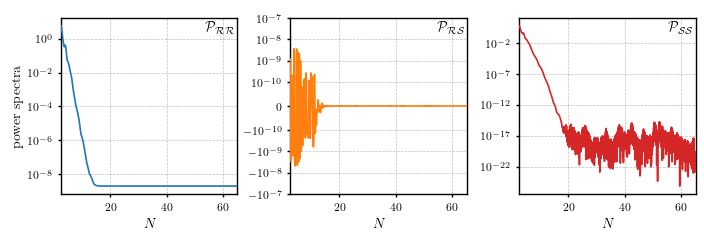

In [120]:
width  = 17.9
aspect = 3

fig = plt.figure(figsize=(cm2inch(width), cm2inch(width/aspect)))

left   = 0.087
bottom = 0.17
height = 0.75
gap    = 0.075
panel_width = 0.25

ax1 = fig.add_axes([left, bottom, panel_width, height])
ax2 = fig.add_axes([left + panel_width + gap, bottom, panel_width, height])
ax3 = fig.add_axes([left + 2*(panel_width + gap), bottom, panel_width, height])

for ax in (ax1, ax2, ax3):
    ax.set_box_aspect(1)

filename = f"ps_mode_grfp.txt"
data     = np.loadtxt(filename)
ax1.plot(data[:,0], data[:,1], ls='-', lw=1.2, color='tab:blue', zorder=5)
ax2.plot(data[:,0], data[:,2], ls='-', lw=1.2, color='tab:orange', zorder=5)
ax3.plot(data[:,0], data[:,4], ls='-', lw=1.2, color='tab:red', zorder=5)

# -------------------------------------------------
# Grid formatting
# -------------------------------------------------
for ax in (ax1, ax2, ax3):
    ax.grid(linestyle='--', color='k', lw=0.5, alpha=0.25)
    ax.tick_params(axis='both', color='black', length=2.5, width=1)
    # ax.tick_params(axis='x', pad=8)
    # ax.tick_params(axis='y', pad=8)
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.set_xlim(data[0,0],data[-1,0])

    # Hide x labels and tick labels for top plots and y ticks for right plots.
    # ax.label_outer()

# Limits
# ax1.set_ylim( 3e-10, 3.5e-10)
ax2.set_ylim(-1e-7,  1e-7)
# ax3.set_ylim( -1e-10, 1e0)

# Log scale
ax1.set_yscale('log')
ax2.set_yscale('symlog', linthresh=1e-10)
# ax2.set_yscale('symlog')
ax3.set_yscale('log')
# ax3.set_yscale('symlog', linthresh=1e-10)

ax1.set_xlabel(r'$N$', fontsize=10)
ax2.set_xlabel(r'$N$', fontsize=10)
ax3.set_xlabel(r'$N$', fontsize=10)
ax1.set_ylabel(r'power spectra', fontsize=10)
ax1.text(0.98, 0.98, r'$\mathcal{P}_{\mathcal{RR}}$', transform=ax1.transAxes, ha='right', va='top', fontsize=10)
ax2.text(0.98, 0.98, r'$\mathcal{P}_{\mathcal{RS}}$', transform=ax2.transAxes, ha='right', va='top', fontsize=10)
ax3.text(0.98, 0.98, r'$\mathcal{P}_{\mathcal{SS}}$', transform=ax3.transAxes, ha='right', va='top', fontsize=10)

plt.savefig(f'ps_mode_grf.pdf')
plt.savefig(f'ps_mode_grf.png', dpi=500, transparent=False)


## Power spectra as a function of k

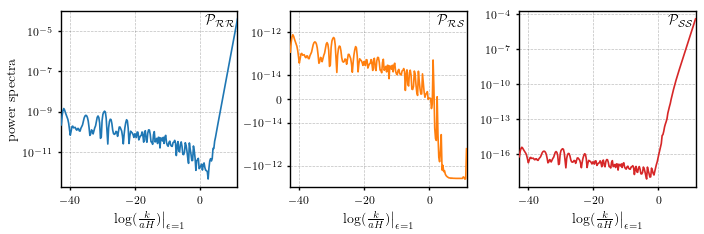

In [11]:
width  = 17.9
aspect = 3

fig = plt.figure(figsize=(cm2inch(width), cm2inch(width/aspect)))

left   = 0.087
bottom = 0.20
height = 0.75
gap    = 0.075
panel_width = 0.25

ax1 = fig.add_axes([left, bottom, panel_width, height])
ax2 = fig.add_axes([left + panel_width + gap, bottom, panel_width, height])
ax3 = fig.add_axes([left + 2*(panel_width + gap), bottom, panel_width, height])

for ax in (ax1, ax2, ax3):
    ax.set_box_aspect(1)

filename = f"ps_full_grf_1.txt"
data     = np.loadtxt(filename)
ax1.plot(data[:,0], data[:,1], ls='-', lw=1.2, color='tab:blue', zorder=5)
ax2.plot(data[:,0], data[:,2], ls='-', lw=1.2, color='tab:orange', zorder=5)
ax3.plot(data[:,0], data[:,4], ls='-', lw=1.2, color='tab:red', zorder=5)

# -------------------------------------------------
# Grid formatting
# -------------------------------------------------
for ax in (ax1, ax2, ax3):
    ax.grid(linestyle='--', color='k', lw=0.5, alpha=0.25)
    ax.tick_params(axis='both', color='black', length=2.5, width=1)
    # ax.tick_params(axis='x', pad=8)
    # ax.tick_params(axis='y', pad=8)
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.set_xlim(data[0,0],data[-1,0])

    # Hide x labels and tick labels for top plots and y ticks for right plots.
    # ax.label_outer()

# Limits
# ax1.set_ylim( 3e-10, 3.5e-10)
ax2.set_ylim(-1e-11,  1e-11)
# ax3.set_ylim( -1e-10, 1e0)

# Log scale
ax1.set_yscale('log')
ax2.set_yscale('symlog', linthresh=1e-14)
# ax2.set_yscale('symlog')
ax3.set_yscale('log')
# ax3.set_yscale('symlog', linthresh=1e-10)

ax1.set_xlabel(r'$\log( \frac{k}{aH} ) \big|_{\epsilon=1}$', fontsize=10)
ax2.set_xlabel(r'$\log( \frac{k}{aH} ) \big|_{\epsilon=1}$', fontsize=10)
ax3.set_xlabel(r'$\log( \frac{k}{aH} ) \big|_{\epsilon=1}$', fontsize=10)
ax1.set_ylabel(r'power spectra', fontsize=10)
ax1.text(0.98, 0.98, r'$\mathcal{P}_{\mathcal{RR}}$', transform=ax1.transAxes, ha='right', va='top', fontsize=10)
ax2.text(0.98, 0.98, r'$\mathcal{P}_{\mathcal{RS}}$', transform=ax2.transAxes, ha='right', va='top', fontsize=10)
ax3.text(0.98, 0.98, r'$\mathcal{P}_{\mathcal{SS}}$', transform=ax3.transAxes, ha='right', va='top', fontsize=10)

plt.savefig(f'ps_full_grf_1.pdf')
plt.savefig(f'ps_full_grf_1.png', dpi=500, transparent=False)

## Power spectra as a function of k for N input files

In [9]:
N = 10 # Number of files

# -------------------------------------------------
# Determine global limits
# -------------------------------------------------
xmin,  xmax  = np.inf, -np.inf
y1min, y1max = np.inf, -np.inf
y2min, y2max = np.inf, -np.inf
y3min, y3max = np.inf, -np.inf

for i in range(1, N + 1):

    filename = f"ps_full_grf_{i}.txt"

    if not os.path.exists(filename):
        continue

    data = np.loadtxt(filename)

    xmin = min(xmin, np.min(data[:,0]))
    xmax = max(xmax, np.max(data[:,0]))

    y1min = min(y1min, np.min(data[:,1]))
    y1max = max(y1max, np.max(data[:,1]))

    y2min = min(y2min, np.min(np.abs(data[:,2])))
    y2max = max(y2max, np.max(np.abs(data[:,2])))

    y3min = min(y3min, np.min(data[:,4]))
    y3max = max(y3max, np.max(data[:,4]))

# -------------------------------------------------
# Generate figures
# -------------------------------------------------
width  = 17.9
aspect = 3
left   = 0.087
bottom = 0.20
height = 0.75
gap    = 0.075
panel_width = 0.25

for i in range(1, N + 1):

    filename = f"ps_full_grf_{i}.txt"

    if not os.path.exists(filename):
        continue
    
    data = np.loadtxt(filename)

    fig = plt.figure(figsize=(cm2inch(width), cm2inch(width/aspect)))

    ax1 = fig.add_axes([left, bottom, panel_width, height])
    ax2 = fig.add_axes([left + panel_width + gap, bottom, panel_width, height])
    ax3 = fig.add_axes([left + 2*(panel_width + gap), bottom, panel_width, height])

    for ax in (ax1, ax2, ax3):
        ax.set_box_aspect(1)

    ax1.plot(data[:,0], data[:,1], ls='-', lw=1.2, color='tab:blue',   zorder=5)
    ax2.plot(data[:,0], np.abs(data[:,2]), ls='-', lw=1.2, color='tab:orange', zorder=5)
    ax3.plot(data[:,0], data[:,4], ls='-', lw=1.2, color='tab:red',    zorder=5)

    # -------------------------------------------------
    # Grid formatting
    # -------------------------------------------------
    for ax in (ax1, ax2, ax3):
        ax.grid(linestyle='--', color='k', lw=0.5, alpha=0.25)
        ax.tick_params(axis='both', color='black', length=2.5, width=1)
        ax.tick_params(axis='both', which='major', labelsize=8)
        ax.set_xlim(xmin, xmax)

    # Fixed limits
    ax1.set_ylim(y1min, y1max)
    ax2.set_ylim(y2min, y2max)
    ax3.set_ylim(y3min, y3max)

    # Log scales
    ax1.set_yscale('log')
    # ax2.set_yscale('symlog', linthresh=1e-14)
    ax2.set_yscale('log')
    ax3.set_yscale('log')

    ax2.set_xlabel(r'$\log( \frac{k}{aH} ) \big|_{\epsilon=1}$', fontsize=10)

    ax1.set_ylabel(r'power spectra', fontsize=10)

    ax1.text(0.98, 0.98, r'$\mathcal{P}_{\mathcal{RR}}$', transform=ax1.transAxes, ha='right', va='top', fontsize=10)
    ax2.text(0.98, 0.98, r'$\mathcal{P}_{\mathcal{RS}}$', transform=ax2.transAxes, ha='right', va='top', fontsize=10)
    ax3.text(0.98, 0.98, r'$\mathcal{P}_{\mathcal{SS}}$', transform=ax3.transAxes, ha='right', va='top', fontsize=10)

    plt.savefig(f'ps_full_grf_{i}.pdf')
    plt.savefig(f'ps_full_grf_{i}.png', dpi=500, transparent=False)
    plt.close(fig)

## Average power spectrum as a function of N

/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1243: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,
/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1650: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


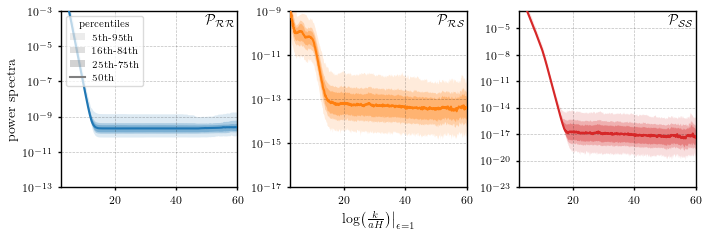

In [4]:
# -------------------------------------------------
# Configuration
# -------------------------------------------------
N           = 1024
percentiles = [(5, 95), (16, 84), (25, 75)]   # outer → inner bands
alphas      = [0.15, 0.25, 0.35]               # matching opacity per band
n_grid      = 500                              # points on common x-grid

# -------------------------------------------------
# Load and interpolate all realizations onto a
# common log-spaced x-grid
# -------------------------------------------------
all_data = []
# xmin_global, xmax_global = -40.75226239, 11.26370321
# xmin_global, xmax_global = -28.47665893, 11.26424725
xmin_global, xmax_global = 2.5 , 60.0
# xmin_global, xmax_global = -np.inf, np.inf

for i in range(1, N + 1):
    filename = f"modes/ps_mode_grf_{i}.txt"
    if not os.path.exists(filename):
        continue
    d = np.loadtxt(filename)
    all_data.append(d)
    # xmin_global = max(xmin_global, np.min(d[:, 0]))
    # xmax_global = min(xmax_global, np.max(d[:, 0]))

if not all_data:
    raise FileNotFoundError("No ps_mode_grf_*.txt files found.")

# Common grid (linear; switch to logspace if x is already log)
x_common = np.linspace(xmin_global, xmax_global, n_grid)

def interpolate_col(data, col, x_grid, take_abs=False):
    y = np.abs(data[:, col]) if take_abs else data[:, col]
    # Use log-interpolation for positive quantities to preserve shape in log-scale plots
    log_y = np.log(np.clip(y, 1e-300, None))
    f = interp1d(data[:, 0], log_y, kind='linear', bounds_error=False, fill_value=np.nan)
    return np.exp(f(x_grid))

# Build (n_realizations x n_grid) arrays for each panel
cols   = [1, 2, 4]
labels = [r'$\mathcal{P}_{\mathcal{RR}}$', r'$\mathcal{P}_{\mathcal{RS}}$', r'$\mathcal{P}_{\mathcal{SS}}$']
colors = ['tab:blue', 'tab:orange', 'tab:red']
take_abs = [False, True, False]   # |P_RS| for middle panel

grids = []
for ci, ab in zip(cols, take_abs):
    stack = np.array([interpolate_col(d, ci, x_common, take_abs=ab) for d in all_data])
    grids.append(stack)   # shape (n_real, n_grid)

# -------------------------------------------------
# Compute statistics (ignoring NaN from extrapolation)
# -------------------------------------------------
means = [np.nanmedian(g, axis=0) for g in grids]
bands = []
for g in grids:
    realization_bands = []
    for (plo, phi) in percentiles:
        lo = np.nanpercentile(g, plo, axis=0)
        hi = np.nanpercentile(g, phi, axis=0)
        realization_bands.append((lo, hi))
    bands.append(realization_bands)

# Global y-limits across all realizations (for consistent axes)

# -------------------------------------------------
# Plot
# -------------------------------------------------
width  = 17.9
aspect = 3
left   = 0.087
bottom = 0.20
height = 0.75
gap    = 0.075
panel_width = 0.25

fig = plt.figure(figsize=(cm2inch(width), cm2inch(width / aspect)))
axes = [
    fig.add_axes([left,                           bottom, panel_width, height]),
    fig.add_axes([left +   panel_width + gap,     bottom, panel_width, height]),
    fig.add_axes([left + 2*(panel_width + gap),   bottom, panel_width, height]),
]
for ax in axes:
    ax.set_box_aspect(1)

for ax, mean, band_list, color, label in zip(axes, means, bands, colors, labels):

    # Percentile bands, outermost first
    for (lo, hi), alpha in zip(band_list, alphas):
        ax.fill_between(x_common, lo, hi, color=color, alpha=alpha, linewidth=0)

    # Mean curve on top
    ax.plot(x_common, mean, color=color, lw=1.5, zorder=5)

    ax.set_yscale('log')
    ax.set_xlim(xmin_global, xmax_global)
    ax.grid(linestyle='--', color='k', lw=0.5, alpha=0.25)
    ax.tick_params(axis='both', color='black', length=2.5, width=1)
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.text(0.98, 0.98, label, transform=ax.transAxes, ha='right', va='top', fontsize=10)

axes[0].set_ylim(1E-13, 1E-3)
axes[1].set_ylim(1E-17, 1E-9)
axes[2].set_ylim(1E-23, 1E-3)

axes[1].set_xlabel(r'$\log\!\left(\frac{k}{aH}\right)\!\big|_{\epsilon=1}$', fontsize=10)
axes[0].set_ylabel(r'power spectra', fontsize=10)

# Legend for percentile bands
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='gray', alpha=alphas[0], label=r'5th-95th'),
    Patch(facecolor='gray', alpha=alphas[1], label=r'16th-84th'),
    Patch(facecolor='gray', alpha=alphas[2], label=r'25th-75th'),
    plt.Line2D([0], [0], color='gray', lw=1.5, label=r'50th'),
]
axes[0].legend(title="percentiles", title_fontsize=7, handles=legend_elements, fontsize=7, loc='upper left', framealpha=0.7, handlelength=1.5)

plt.savefig('modes/ps_mode_mean_bands.pdf')
plt.savefig('modes/ps_mode_mean_bands.png', dpi=500, transparent=False)
# plt.close(fig)

## Average power spectra as a function of k

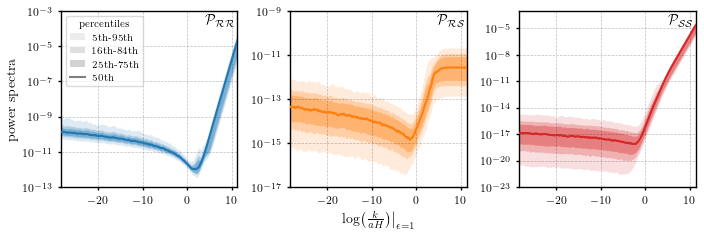

In [5]:
# -------------------------------------------------
# Configuration
# -------------------------------------------------
N           = 1024
percentiles = [(5, 95), (16, 84), (25, 75)]   # outer → inner bands
alphas      = [0.15, 0.25, 0.35]               # matching opacity per band
n_grid      = 500                              # points on common x-grid

# -------------------------------------------------
# Load and interpolate all realizations onto a
# common log-spaced x-grid
# -------------------------------------------------
all_data = []
# xmin_global, xmax_global = -40.75226239, 11.26370321
# xmin_global, xmax_global = -28.47665893, 11.26424725
xmin_global, xmax_global = -np.inf, np.inf

for i in range(1, N + 1):
    filename = f"spectra/ps_full_grf_{i}.txt"
    if not os.path.exists(filename):
        continue
    d = np.loadtxt(filename)
    all_data.append(d)
    xmin_global = max(xmin_global, np.min(d[:, 0]))
    xmax_global = min(xmax_global, np.max(d[:, 0]))

if not all_data:
    raise FileNotFoundError("No ps_full_grf_*.txt files found.")

# Common grid (linear; switch to logspace if x is already log)
x_common = np.linspace(xmin_global, xmax_global, n_grid)

def interpolate_col(data, col, x_grid, take_abs=False):
    y = np.abs(data[:, col]) if take_abs else data[:, col]
    # Use log-interpolation for positive quantities to preserve shape in log-scale plots
    log_y = np.log(np.clip(y, 1e-300, None))
    f = interp1d(data[:, 0], log_y, kind='linear', bounds_error=False, fill_value=np.nan)
    return np.exp(f(x_grid))

# Build (n_realizations x n_grid) arrays for each panel
cols   = [1, 2, 4]
labels = [r'$\mathcal{P}_{\mathcal{RR}}$', r'$\mathcal{P}_{\mathcal{RS}}$', r'$\mathcal{P}_{\mathcal{SS}}$']
colors = ['tab:blue', 'tab:orange', 'tab:red']
take_abs = [False, True, False]   # |P_RS| for middle panel

grids = []
for ci, ab in zip(cols, take_abs):
    stack = np.array([interpolate_col(d, ci, x_common, take_abs=ab) for d in all_data])
    grids.append(stack)   # shape (n_real, n_grid)

# -------------------------------------------------
# Compute statistics (ignoring NaN from extrapolation)
# -------------------------------------------------
means = [np.nanmedian(g, axis=0) for g in grids]
bands = []
for g in grids:
    realization_bands = []
    for (plo, phi) in percentiles:
        lo = np.nanpercentile(g, plo, axis=0)
        hi = np.nanpercentile(g, phi, axis=0)
        realization_bands.append((lo, hi))
    bands.append(realization_bands)

# Global y-limits across all realizations (for consistent axes)

# -------------------------------------------------
# Plot
# -------------------------------------------------
width  = 17.9
aspect = 3
left   = 0.087
bottom = 0.20
height = 0.75
gap    = 0.075
panel_width = 0.25

fig = plt.figure(figsize=(cm2inch(width), cm2inch(width / aspect)))
axes = [
    fig.add_axes([left,                           bottom, panel_width, height]),
    fig.add_axes([left +   panel_width + gap,     bottom, panel_width, height]),
    fig.add_axes([left + 2*(panel_width + gap),   bottom, panel_width, height]),
]
for ax in axes:
    ax.set_box_aspect(1)

for ax, mean, band_list, color, label in zip(axes, means, bands, colors, labels):

    # Percentile bands, outermost first
    for (lo, hi), alpha in zip(band_list, alphas):
        ax.fill_between(x_common, lo, hi, color=color, alpha=alpha, linewidth=0)

    # Mean curve on top
    ax.plot(x_common, mean, color=color, lw=1.5, zorder=5)

    ax.set_yscale('log')
    ax.set_xlim(xmin_global, xmax_global)
    ax.grid(linestyle='--', color='k', lw=0.5, alpha=0.25)
    ax.tick_params(axis='both', color='black', length=2.5, width=1)
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.text(0.98, 0.98, label, transform=ax.transAxes, ha='right', va='top', fontsize=10)

axes[0].set_ylim(1E-13, 1E-3)
axes[1].set_ylim(1E-17, 1E-9)
axes[2].set_ylim(1E-23, 1E-3)

axes[1].set_xlabel(r'$\log\!\left(\frac{k}{aH}\right)\!\big|_{\epsilon=1}$', fontsize=10)
axes[0].set_ylabel(r'power spectra', fontsize=10)

# Legend for percentile bands
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='gray', alpha=alphas[0], label=r'5th-95th'),
    Patch(facecolor='gray', alpha=alphas[1], label=r'16th-84th'),
    Patch(facecolor='gray', alpha=alphas[2], label=r'25th-75th'),
    plt.Line2D([0], [0], color='gray', lw=1.5, label=r'50th'),
]
axes[0].legend(title="percentiles", title_fontsize=7, handles=legend_elements, fontsize=7, loc='upper left', framealpha=0.7, handlelength=1.5)

plt.savefig('ps_mean_bands.pdf')
plt.savefig('ps_mean_bands.png', dpi=500, transparent=False)
# plt.close(fig)

## Slow-roll/slow-turn parameters

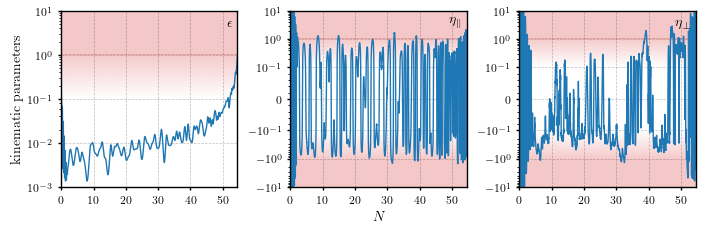

In [47]:
from matplotlib.ticker import FixedLocator, NullFormatter
from matplotlib.colors import to_rgb

def symlog_minor_tick_locations(ymin, ymax, linthresh, linear_subdivisions=5, log_subs=np.arange(2, 10)):
    """
    Construct minor-tick positions for both parts of a symlog axis.

    linear_subdivisions=5 places four minor ticks between 0 and
    +/-linthresh.
    """
    minor_ticks = []

    # -------------------------------------------------------------
    # Minor ticks in the linear region: -linthresh < y < linthresh
    # -------------------------------------------------------------
    linear_step = linthresh / linear_subdivisions
    linear_min = max(ymin, -linthresh)
    linear_max = min(ymax,  linthresh)

    if linear_min < linear_max:
        kmin = int(np.ceil(linear_min / linear_step))
        kmax = int(np.floor(linear_max / linear_step))

        for k in range(kmin, kmax + 1):
            value = k * linear_step

            # Exclude zero and the boundaries of the linear region,
            # since these are major-tick locations.
            if (not np.isclose(value, 0.0) and not np.isclose(abs(value), linthresh)):
                minor_ticks.append(value)

    # -------------------------------------------------------------
    # Minor ticks in the positive and negative logarithmic regions
    # -------------------------------------------------------------
    max_abs_value = max(abs(ymin), abs(ymax))

    if max_abs_value > linthresh:
        exponent_min = int(np.floor(np.log10(linthresh)))
        exponent_max = int(np.ceil(np.log10(max_abs_value)))

        for exponent in range(exponent_min, exponent_max + 1):
            decade = 10.0**exponent

            for sub in log_subs:
                value = sub * decade

                if linthresh < value < ymax:
                    minor_ticks.append(value)

                if ymin < -value < -linthresh:
                    minor_ticks.append(-value)

    return np.unique(np.asarray(minor_ticks))

def fading_hspan(ax, y_threshold=1.0, fade_to=0.1, color="tab:red", max_alpha=0.20, n_steps=512, zorder=0, mode="upper"):
    """
    Shade y >= y_threshold ("upper") or y <= y_threshold ("lower") with
    constant opacity, and fade the shading linearly from max_alpha to zero
    between fade_to and y_threshold.

    The gradient is constructed in axes coordinates, so it remains
    visually uniform on logarithmic and symlogarithmic axes.

    Parameters
    ----------
    mode : {"upper", "lower"}
        "upper" shades y >= y_threshold (fade_to must be < y_threshold).
        "lower" shades y <= y_threshold (fade_to must be > y_threshold).
    """
    if mode not in ("upper", "lower"):
        raise ValueError('mode must be "upper" or "lower".')

    ymin, ymax = ax.get_ylim()

    if mode == "upper":
        if not ymin <= fade_to < y_threshold <= ymax:
            raise ValueError("Require ymin <= fade_to < y_threshold <= ymax for mode='upper'.")
        # Constant shading above the threshold.
        ax.axhspan(y_threshold, ymax, facecolor=color, alpha=max_alpha, edgecolor="none", zorder=zorder)
        fade_lo, fade_hi = fade_to, y_threshold
        alpha_lo, alpha_hi = 0.0, max_alpha
    else:
        if not ymin <= y_threshold < fade_to <= ymax:
            raise ValueError("Require ymin <= y_threshold < fade_to <= ymax for mode='lower'.")
        # Constant shading below the threshold.
        ax.axhspan(ymin, y_threshold, facecolor=color, alpha=max_alpha, edgecolor="none", zorder=zorder)
        fade_lo, fade_hi = y_threshold, fade_to
        alpha_lo, alpha_hi = max_alpha, 0.0

    # Convert the two data-space y-values to axes coordinates.
    inverse_axes_transform = ax.transAxes.inverted()

    y_fade_lo_axes = inverse_axes_transform.transform(ax.transData.transform((0.0, fade_lo)))[1]
    y_fade_hi_axes = inverse_axes_transform.transform(ax.transData.transform((0.0, fade_hi)))[1]

    # RGBA image whose opacity varies linearly between alpha_lo and alpha_hi.
    rgb = to_rgb(color)

    gradient = np.empty((n_steps, 1, 4))
    gradient[:, :, 0] = rgb[0]
    gradient[:, :, 1] = rgb[1]
    gradient[:, :, 2] = rgb[2]
    gradient[:, :, 3] = np.linspace(alpha_lo, alpha_hi, n_steps)[:, None]

    ax.imshow(gradient, origin="lower", extent=(0.0, 1.0, y_fade_lo_axes, y_fade_hi_axes), transform=ax.transAxes, aspect="auto", interpolation="bilinear", zorder=zorder, clip_on=True)

# -------------------------------------------------
# Load and interpolate all realizations onto a
# common log-spaced x-grid
# -------------------------------------------------
all_data = []
# xmin_global, xmax_global = -40.75226239, 11.26370321
# xmin_global, xmax_global = -28.47665893, 11.26424725
xmin_global, xmax_global = -np.inf, np.inf

filename = f"trajs/traj_4.txt"
d = np.loadtxt(filename)

# Build (n_realizations x n_grid) arrays for each panel
cols   = [1, 2, 4]
labels = [r'$\epsilon$', r'$\eta_{\parallel}$', r'$\eta_{\perp}$']
colors = ['tab:blue', 'tab:blue', 'tab:blue']
curves = [d[:,6], (d[:,7]), (d[:,8])]
x = d[:,5]

# -------------------------------------------------
# Plot
# -------------------------------------------------
width  = 17.9
aspect = 3
left   = 0.087
bottom = 0.20
height = 0.75
gap    = 0.075
panel_width = 0.25

fig = plt.figure(figsize=(cm2inch(width), cm2inch(width / aspect)))
axes = [
    fig.add_axes([left,                           bottom, panel_width, height]),
    fig.add_axes([left +   panel_width + gap,     bottom, panel_width, height]),
    fig.add_axes([left + 2*(panel_width + gap),   bottom, panel_width, height]),
]
for ax in axes:
    ax.set_box_aspect(1)

minor_y_ticks = symlog_minor_tick_locations(ymin=-1E1, ymax=1E1, linthresh=1E-1, linear_subdivisions=5, log_subs=np.arange(2, 10))

for ax, color, label, curve in zip(axes, colors, labels, curves):
    # Mean curve on top
    ax.plot(x, curve, color=color, lw=1.0)
    # ax.set_yscale('log')
    ax.set_xlim(0, x[-1])
    ax.grid(linestyle='--', color='k', lw=0.5, alpha=0.25)
    ax.text(0.97, 0.97, label, transform=ax.transAxes, ha='right', va='top', fontsize=10)
    ax.set_xticks(np.linspace(0,50,6))
    # ax.set_ylim(-4E-3, 1E1)
    ax.set_yscale("symlog", linthresh=1E-2)
    ax.tick_params(axis='both', color='black', length=2.5, width=1)
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.tick_params(axis="y", which="minor", color="black", length=1.5, width=0.6)

axes[0].set_ylim( 1E-3, 1E1)
axes[1].set_ylim(-1E1, 1E1)
axes[2].set_ylim(-1E1, 1E1)

# axes[0].set_yscale("symlog", linthresh=1E-4)
# axes[1].set_yscale("symlog", linthresh=1E-4)
# axes[2].set_yscale("symlog", linthresh=1E-4)
axes[0].set_yscale("log")
axes[1].set_yscale("symlog", linthresh=1E-1)
axes[2].set_yscale("symlog", linthresh=1E-1)

# Now that ylim/yscale are final, draw all fading spans
for ax in axes:
    fading_hspan(ax, y_threshold=1E0, fade_to=1E-1, color="tab:red", max_alpha=0.25, mode="upper")
    ax.yaxis.set_minor_locator(FixedLocator(minor_y_ticks))
    ax.yaxis.set_minor_formatter(NullFormatter())

fading_hspan(axes[1], y_threshold=-1E0, fade_to=-1E-1, color="tab:red", max_alpha=0.25, mode="lower")
fading_hspan(axes[2], y_threshold=-1E0, fade_to=-1E-1, color="tab:red", max_alpha=0.25, mode="lower")

axes[1].set_xlabel(r'$N$', fontsize=10)
axes[0].set_ylabel(r'kinematic parameters', fontsize=10)

plt.savefig('srst_params.pdf')
plt.savefig('srst_params.png', dpi=500, transparent=False)

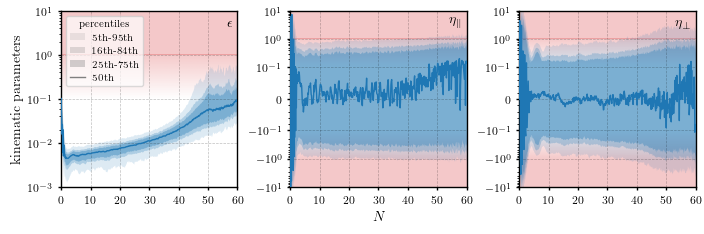

In [54]:
from scipy.interpolate import interp1d
from matplotlib.ticker import FixedLocator, NullFormatter
from matplotlib.colors import to_rgb

def symlog_minor_tick_locations(ymin, ymax, linthresh, linear_subdivisions=5, log_subs=np.arange(2, 10)):
    """
    Construct minor-tick positions for both parts of a symlog axis.

    linear_subdivisions=5 places four minor ticks between 0 and
    +/-linthresh.
    """
    minor_ticks = []

    linear_step = linthresh / linear_subdivisions
    linear_min = max(ymin, -linthresh)
    linear_max = min(ymax,  linthresh)

    if linear_min < linear_max:
        kmin = int(np.ceil(linear_min / linear_step))
        kmax = int(np.floor(linear_max / linear_step))

        for k in range(kmin, kmax + 1):
            value = k * linear_step
            if (not np.isclose(value, 0.0) and not np.isclose(abs(value), linthresh)):
                minor_ticks.append(value)

    max_abs_value = max(abs(ymin), abs(ymax))

    if max_abs_value > linthresh:
        exponent_min = int(np.floor(np.log10(linthresh)))
        exponent_max = int(np.ceil(np.log10(max_abs_value)))

        for exponent in range(exponent_min, exponent_max + 1):
            decade = 10.0**exponent
            for sub in log_subs:
                value = sub * decade
                if linthresh < value < ymax:
                    minor_ticks.append(value)
                if ymin < -value < -linthresh:
                    minor_ticks.append(-value)

    return np.unique(np.asarray(minor_ticks))

def fading_hspan(ax, y_threshold=1.0, fade_to=0.1, color="tab:red", max_alpha=0.20, n_steps=512, zorder=0, mode="upper"):
    """
    Shade y >= y_threshold ("upper") or y <= y_threshold ("lower") with
    constant opacity, and fade the shading linearly from max_alpha to zero
    between fade_to and y_threshold.
    """
    if mode not in ("upper", "lower"):
        raise ValueError('mode must be "upper" or "lower".')

    ymin, ymax = ax.get_ylim()

    if mode == "upper":
        if not ymin <= fade_to < y_threshold <= ymax:
            raise ValueError("Require ymin <= fade_to < y_threshold <= ymax for mode='upper'.")
        ax.axhspan(y_threshold, ymax, facecolor=color, alpha=max_alpha, edgecolor="none", zorder=zorder)
        fade_lo, fade_hi = fade_to, y_threshold
        alpha_lo, alpha_hi = 0.0, max_alpha
    else:
        if not ymin <= y_threshold < fade_to <= ymax:
            raise ValueError("Require ymin <= y_threshold < fade_to <= ymax for mode='lower'.")
        ax.axhspan(ymin, y_threshold, facecolor=color, alpha=max_alpha, edgecolor="none", zorder=zorder)
        fade_lo, fade_hi = y_threshold, fade_to
        alpha_lo, alpha_hi = max_alpha, 0.0

    inverse_axes_transform = ax.transAxes.inverted()
    y_fade_lo_axes = inverse_axes_transform.transform(ax.transData.transform((0.0, fade_lo)))[1]
    y_fade_hi_axes = inverse_axes_transform.transform(ax.transData.transform((0.0, fade_hi)))[1]

    rgb = to_rgb(color)
    gradient = np.empty((n_steps, 1, 4))
    gradient[:, :, 0] = rgb[0]
    gradient[:, :, 1] = rgb[1]
    gradient[:, :, 2] = rgb[2]
    gradient[:, :, 3] = np.linspace(alpha_lo, alpha_hi, n_steps)[:, None]

    ax.imshow(gradient, origin="lower", extent=(0.0, 1.0, y_fade_lo_axes, y_fade_hi_axes), transform=ax.transAxes, aspect="auto", interpolation="bilinear", zorder=zorder, clip_on=True)

# -------------------------------------------------
# Configuration
# -------------------------------------------------
N           = 1024
percentiles = [(5, 95), (16, 84), (25, 75)]   # outer → inner bands
alphas      = [0.15, 0.25, 0.35]               # matching opacity per band
n_grid      = 500                              # points on common N-grid

# -------------------------------------------------
# Load and interpolate all trajectories onto a
# common N (e-fold) grid
# -------------------------------------------------
all_data = []
xmin_global, xmax_global = -np.inf, np.inf

for i in range(1, N + 1):
    filename = f"trajs/traj_{i}.txt"
    if not os.path.exists(filename):
        continue
    d = np.loadtxt(filename)
    all_data.append(d)
    # xmin_global = max(xmin_global, np.min(d[:, 5]))
    # xmax_global = min(xmax_global, np.max(d[:, 5]))

if not all_data:
    raise FileNotFoundError("No trajs/traj_*.txt files found.")

xmin_global = 0
xmax_global = 60
x_common = np.linspace(xmin_global, xmax_global, n_grid)

def interpolate_col(data, col, x_grid, log_interp=False):
    x = data[:, 5]
    y = data[:, col]
    if log_interp:
        # Only safe for strictly positive quantities (e.g. epsilon)
        y_work = np.log(np.clip(y, 1e-300, None))
    else:
        y_work = y
    f = interp1d(x, y_work, kind='linear', bounds_error=False, fill_value=np.nan)
    y_grid = f(x_grid)
    return np.exp(y_grid) if log_interp else y_grid

# Build (n_traj x n_grid) arrays for each panel
cols       = [6, 7, 8]
labels     = [r'$\epsilon$', r'$\eta_{\parallel}$', r'$\eta_{\perp}$']
colors     = ['tab:blue', 'tab:blue', 'tab:blue']
log_interp = [True, False, False]   # eps > 0 always -> log interp; eta_par/eta_perp can change sign -> linear

grids = []
for ci, li in zip(cols, log_interp):
    stack = np.array([interpolate_col(d, ci, x_common, log_interp=li) for d in all_data])
    grids.append(stack)   # shape (n_traj, n_grid)

# -------------------------------------------------
# Compute statistics (ignoring NaN from extrapolation
# where a trajectory ended before x_common's upper edge,
# etc.)
# -------------------------------------------------
medians = [np.nanmedian(g, axis=0) for g in grids]
bands = []
for g in grids:
    traj_bands = []
    for (plo, phi) in percentiles:
        lo = np.nanpercentile(g, plo, axis=0)
        hi = np.nanpercentile(g, phi, axis=0)
        traj_bands.append((lo, hi))
    bands.append(traj_bands)

# -------------------------------------------------
# Plot
# -------------------------------------------------
width  = 17.9
aspect = 3
left   = 0.087
bottom = 0.20
height = 0.75
gap    = 0.075
panel_width = 0.25

fig = plt.figure(figsize=(cm2inch(width), cm2inch(width / aspect)))
axes = [
    fig.add_axes([left,                           bottom, panel_width, height]),
    fig.add_axes([left +   panel_width + gap,     bottom, panel_width, height]),
    fig.add_axes([left + 2*(panel_width + gap),   bottom, panel_width, height]),
]
for ax in axes:
    ax.set_box_aspect(1)

minor_y_ticks = symlog_minor_tick_locations(ymin=-1E1, ymax=1E1, linthresh=1E-1, linear_subdivisions=5, log_subs=np.arange(2, 10))

for ax, color, label, median, band_list in zip(axes, colors, labels, medians, bands):

    # Percentile bands, outermost first
    for (lo, hi), alpha in zip(band_list, alphas):
        ax.fill_between(x_common, lo, hi, color=color, alpha=alpha, linewidth=0)

    # Median curve on top
    ax.plot(x_common, median, color=color, lw=1.0, zorder=5)

    ax.set_xlim(x_common[0], x_common[-1])
    ax.set_xticks(np.linspace(0,60,7))
    ax.grid(linestyle='--', color='k', lw=0.5, alpha=0.25)
    ax.text(0.97, 0.97, label, transform=ax.transAxes, ha='right', va='top', fontsize=10)
    # ax.set_xticks(np.linspace(x_common[0], x_common[-1], 6))
    ax.tick_params(axis='both', color='black', length=2.5, width=1)
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.tick_params(axis="y", which="minor", color="black", length=1.5, width=0.6)

axes[0].set_ylim( 1E-3, 1E1)
axes[1].set_ylim(-1E1, 1E1)
axes[2].set_ylim(-1E1, 1E1)

axes[0].set_yscale("log")
axes[1].set_yscale("symlog", linthresh=1E-1)
axes[2].set_yscale("symlog", linthresh=1E-1)

# Now that ylim/yscale are final, draw all fading spans
for ax in axes:
    fading_hspan(ax, y_threshold=1E0, fade_to=1E-1, color="tab:red", max_alpha=0.25, mode="upper")
    ax.yaxis.set_minor_locator(FixedLocator(minor_y_ticks))
    ax.yaxis.set_minor_formatter(NullFormatter())

fading_hspan(axes[1], y_threshold=-1E0, fade_to=-1E-1, color="tab:red", max_alpha=0.25, mode="lower")
fading_hspan(axes[2], y_threshold=-1E0, fade_to=-1E-1, color="tab:red", max_alpha=0.25, mode="lower")

axes[1].set_xlabel(r'$N$', fontsize=10)
axes[0].set_ylabel(r'kinematic parameters', fontsize=10)

# Legend for percentile bands
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='gray', alpha=alphas[0], label=r'5th-95th'),
    Patch(facecolor='gray', alpha=alphas[1], label=r'16th-84th'),
    Patch(facecolor='gray', alpha=alphas[2], label=r'25th-75th'),
    plt.Line2D([0], [0], color='gray', lw=1.0, label=r'50th'),
]
axes[0].legend(title="percentiles", title_fontsize=7, handles=legend_elements, fontsize=7, loc='upper left', framealpha=0.7, handlelength=1.5)

plt.savefig('srst_mean_bands.pdf')
plt.savefig('srst_mean_bands.png', dpi=500, transparent=False)

## Background trajectories

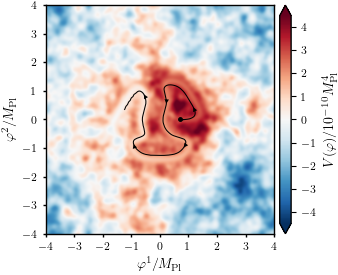

In [13]:
#  Potential colormap and trajectories for non-linear potential

# Parameters
half_square_side   = 4.0
phi1_min, phi1_max = -half_square_side, half_square_side
phi2_min, phi2_max = -half_square_side, half_square_side
width              = 8.6
aspect             = 1.23
colormap           = "RdBu_r"
ntrajs             = 8

# Load data
potential = np.loadtxt(f'potential_1.txt')
ngrid = potential.shape[0]

# Coordinate axes
phi1   = np.linspace(phi1_min, phi1_max, ngrid)
phi2   = np.linspace(phi2_min, phi2_max, ngrid)
extent = [phi1_min, phi1_max, phi2_min, phi2_max]

# Create figure
fig = plt.figure(figsize=(cm2inch(width), cm2inch(width/aspect)))
ax = fig.add_axes([0.0625, 0.15, 0.83, 0.83])  # [left, bottom, width, height]
ax.set_box_aspect(1)

# Plot
im = ax.imshow(potential/1E-10, origin='lower', extent=extent, aspect='auto', cmap=colormap, interpolation='bicubic', alpha=1.0, vmin=-4.5, vmax=4.5)
# im = ax.imshow(potential, origin='lower', extent=extent, aspect='auto', cmap=colormap, interpolation='none')

# Tell Matplotlib not to epand the data limits when drawing arrows
ax.autoscale(False)

traj = np.loadtxt(f"traj_1.txt")

ax.plot(traj[:, 0], traj[:, 1], linestyle='-', color='black', lw=0.75, alpha=1.0)
ax.plot(traj[0, 0], traj[0, 1], 'o', color='black', markersize=2.5, alpha=1.0)
# ax.plot(traj[idx, 0], traj[idx, 1], 'o', color='salmon', markersize=1.5, alpha=1.0)
arrowhead(ax, traj[: , :2], d=1.0, c='black', hw=1.0, hl=0.8)
# arrowhead(ax, traj[: , :2], d=1.0, c='black', hw=1.0, hl=0.8)
arrowhead(ax, traj[: , :2], d=3.0, c='black', hw=1.0, hl=0.8)
# arrowhead(ax, traj[: , :2], d=2.0, c='black', hw=1.0, hl=0.8)
arrowhead(ax, traj[: , :2], d=5.0, c='black', hw=1.0, hl=0.8)
# arrowhead(ax, traj[: , :2], d=3.0, c='black', hw=1.0, hl=0.8)
arrowhead(ax, traj[: , :2], d=7.0, c='black', hw=1.0, hl=0.8)
# arrowhead(ax, traj[: , :2], d=4.0, c='black', hw=1.0, hl=0.8)
arrowhead(ax, traj[: , :2], d=9.0, c='black', hw=1.0, hl=0.8)
# arrowhead(ax, traj[: , :2], d=5.0, c='black', hw=1.0, hl=0.8)
arrowhead(ax, traj[: , :2], d=11.0, c='black', hw=1.0, hl=0.8)
# arrowhead(ax, traj[: , :2], d=6.0, c='black', hw=1.0, hl=0.8)

# =============================================================================
# Axis formatting
# =============================================================================
# ax.set_title(fr'$\alpha = \beta = 1$', fontsize=10)
ax.set_xlabel(r'$\varphi^1 / M_{\mathrm{Pl}}$', fontsize=10)
ax.set_ylabel(r'$\varphi^2 / M_{\mathrm{Pl}}$', fontsize=10)
ax.tick_params(axis='both', which='major', labelsize=8, length=2.5, width=1)
ticks = np.linspace(phi1_min, phi1_max, 9)
ax.set_xticks(ticks)
ax.set_yticks(ticks)

# =============================================================================
# Colorbar
# =============================================================================
cbar = fig.colorbar(im, ax=ax, pad=0.02, fraction=0.08, shrink=1, extend="both")
cbar.set_label(r'$V(\varphi) / 10^{-10} M_{\mathrm{Pl}}^{4}$', fontsize=10)
cbar.ax.tick_params(labelsize=8)

# Save to PDF
plt.savefig(f'traj_1.pdf')
plt.savefig(f'traj_1.png', dpi=500, transparent=False)

## Histogram of e-folds

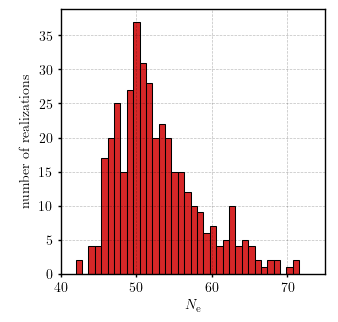

In [6]:
plt.ion()
 
# number of data files (change this as needed)
N = 400
 
# directory / filename pattern
path = "trajs/traj_{}.txt"
 
# collect the e-fold count at the end of inflation (last row, 6th column) for each file
efolds = []
 
for i in range(1, N+1):
	filename = path.format(i)
	if not os.path.exists(filename):
		continue
	data = np.loadtxt(filename)
	efolds.append(data[-1, 5])
 
#######################################################################
 
width  = 8.6
aspect = 1.05
 
# Create figure
fig = plt.figure(figsize=(cm2inch(width), cm2inch(width/aspect)))
ax = fig.add_axes([0.16, 0.15, 0.82, 0.82])  # [left, bottom, width, height]
ax.set_box_aspect(1)
 
# Add grid
ax.grid(linestyle='--', color='k', lw=0.5, alpha=0.25)
 
# Histogram of e-folds at end of inflation
ax.hist(efolds, bins=35, color='tab:red', edgecolor='k', linewidth=0.75, alpha=1.0)
 
# Add vertical line
# ax.axvline(x=60, color='k', linestyle='-', linewidth=0.5, alpha=1.0)
# ax.text(60 + 0.5, ax.get_ylim()[1]*0.5, 'tolerance', rotation=90, verticalalignment='bottom', fontsize=8, alpha=0.7)
 
# =============================================================================
# Formatting
# =============================================================================
ax.tick_params(axis='both', color='black', length=2.5, width=1)
ax.set_xlim(40, 75)
ax.set_xlabel(r'$N_{\rm e}$', fontsize=10)
ax.set_ylabel(r'number of realizations', fontsize=10)
ax.tick_params(axis='both', which='major', labelsize=10)
 
# Save
plt.savefig('efolds_histogram.pdf')
plt.savefig(f'efolds_histogram.png', dpi=500, transparent=False)
plt.show()

## KDE (smoothed density curve) + rug plot

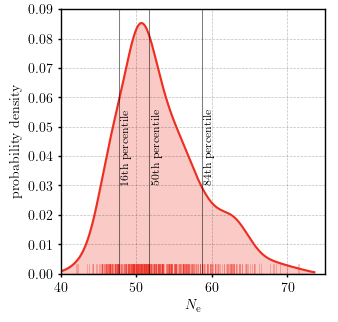

In [6]:
from scipy.stats import gaussian_kde
 
plt.ion()
 
# number of data files (change this as needed)
N = 500
 
# directory / filename pattern
path = "trajs/traj_{}.txt"
 
# collect the e-fold count at the end of inflation (last row, 6th column) for each file
efolds = []
 
for i in range(1, N+1):
	filename = path.format(i)
	if not os.path.exists(filename):
		continue
	data = np.loadtxt(filename)
	efolds.append(data[-1, 5])
 
#######################################################################
 
width  = 8.6
aspect = 1.05
 
# Create figure
fig = plt.figure(figsize=(cm2inch(width), cm2inch(width/aspect)))
ax = fig.add_axes([0.16, 0.15, 0.82, 0.82])  # [left, bottom, width, height]
ax.set_box_aspect(1)
 
# Add grid
ax.grid(linestyle='--', color='k', lw=0.5, alpha=0.25)
 
# Get the colormap
cmap = colormaps['YlOrRd_r']
 
# Kernel density estimate
kde = gaussian_kde(efolds)
xgrid = np.linspace(np.min(efolds)-2.0, np.max(efolds)+2.0, 512)
density = kde(xgrid)
 
ax.plot(xgrid, density, color=cmap(0.3), ls="-", lw=1.5, alpha=1.0)
ax.fill_between(xgrid, 0.0, density, color=cmap(0.3), alpha=0.25)
 
# Rug plot: one tick per realization along the x-axis
rug_height = 0.04 * density.max()
ax.plot(np.tile(efolds, (2,1)), np.tile([[0.0],[rug_height]], (1,np.size(efolds))), color=cmap(0.3), lw=0.5, alpha=0.4)
 
# Add horizontal lines at the median and the 16-84 percentile band
median = np.median(efolds)
lo, hi = np.percentile(efolds, [16, 84])
ax.axvline(x=median, color='k', linestyle='-', linewidth=0.75, alpha=0.5)
ax.axvline(x=lo, color='k', linestyle='-', linewidth=0.75, alpha=0.5)
ax.axvline(x=hi, color='k', linestyle='-', linewidth=0.75, alpha=0.5)

# =============================================================================
# Formatting
# =============================================================================
ax.tick_params(axis='both', color='black', length=2.5, width=1)
# ax.set_xlim(np.min(efolds), np.max(efolds))
ax.set_xlim(40, 75)
ax.set_ylim(0.0, 0.09)
ax.set_xlabel(r'$N_{\rm e}$', fontsize=10)
ax.set_ylabel(r'$\mathrm{probability\ density}$', fontsize=10)
ax.tick_params(axis='both', which='major', labelsize=10)

ax.text(    lo + 0.3, 0.03, '16th percentile', rotation=90, verticalalignment='bottom', fontsize=8, alpha=1.0)
ax.text(median + 0.3, 0.03, '50th percentile', rotation=90, verticalalignment='bottom', fontsize=8, alpha=1.0)
ax.text(    hi + 0.3, 0.03, '84th percentile', rotation=90, verticalalignment='bottom', fontsize=8, alpha=1.0)
 
# Save
plt.savefig('efolds_kde.pdf')
plt.savefig(f'efolds_kde.png', dpi=500, transparent=False)
plt.show()

## ECDF (empirical cumulative distribution) plot

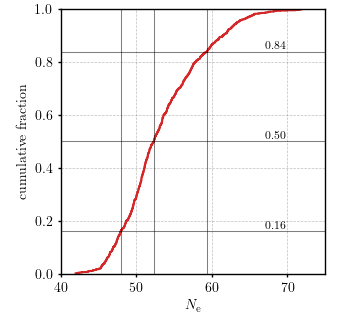

In [5]:
plt.ion()
 
# number of data files (change this as needed)
N = 1024
 
# directory / filename pattern
path = "trajs/traj_{}.txt"
 
# collect the e-fold count at the end of inflation (last row, 6th column) for each file
efolds = []
 
for i in range(1, N+1):
	filename = path.format(i)
	if not os.path.exists(filename):
		continue
	data = np.loadtxt(filename)
	efolds.append(data[-1, 5])
 
#######################################################################
 
width  = 8.6
aspect = 1.05
 
# Create figure
fig = plt.figure(figsize=(cm2inch(width), cm2inch(width/aspect)))
ax = fig.add_axes([0.16, 0.15, 0.82, 0.82])  # [left, bottom, width, height]
ax.set_box_aspect(1)
 
# Add grid
ax.grid(linestyle='--', color='k', lw=0.5, alpha=0.25)

# =============================================================================
# Empirical CDF
# =============================================================================
xsorted = np.sort(efolds)
cdf = np.arange(1, np.size(efolds)+1) / np.size(efolds)
 
ax.step(xsorted, cdf, where='post', color='tab:red', lw=1.5, alpha=1.0)
 
# Add horizontal lines at the median and the 16-84 percentile band
median = np.median(efolds)
lo, hi = np.percentile(efolds, [16, 84])
ax.axhline(y=0.16, color='k', linestyle='-', linewidth=0.75, alpha=0.5)
ax.axhline(y=0.50, color='k', linestyle='-', linewidth=0.75, alpha=0.5)
ax.axhline(y=0.84, color='k', linestyle='-', linewidth=0.75, alpha=0.5)
ax.axvline(x=median, color='k', linestyle='-', linewidth=0.75, alpha=0.5)
ax.axvline(x=lo, color='k', linestyle='-', linewidth=0.75, alpha=0.5)
ax.axvline(x=hi, color='k', linestyle='-', linewidth=0.75, alpha=0.5)
 
# =============================================================================
# Formatting
# =============================================================================
ax.tick_params(axis='both', color='black', length=2.5, width=1)
# ax.set_xlim(np.min(efolds), np.max(efolds))
ax.set_xlim(40, 75)
ax.set_ylim(0.0, 1.0)
ax.set_xlabel(r'$N_{\rm e}$', fontsize=10)
ax.set_ylabel(r'$\mathrm{cumulative\ fraction}$', fontsize=10)
ax.tick_params(axis='both', which='major', labelsize=10)

ax.text(67, 0.88, '0.84', rotation=0, verticalalignment='top', fontsize=8, alpha=1.0)
ax.text(67, 0.54, '0.50', rotation=0, verticalalignment='top', fontsize=8, alpha=1.0)
ax.text(67, 0.20, '0.16', rotation=0, verticalalignment='top', fontsize=8, alpha=1.0)
 
# Save
plt.savefig('efolds_ecdf.pdf')
plt.savefig(f'efolds_ecdf.png', dpi=500, transparent=False)
plt.show()
 